<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_L1_65456.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_65456_1**
Wprowadzenie do programowania w Python w środowisku *Colab*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
!python --version

Python 3.11.11


### **Zad 1.** Mamy funkcję $\qquad f(x) = x + |\sin(32x)|,\quad gdzie: x \in (0, 4].\quad$ Oblicz jej wartość na końcu przedziału. Jak sądzisz? Czy obliczona wartość, to będzie max funkcji $f(x)$?

In [ ]:
# import numpy as np
# Wartość funkcji w punkcie:

x = 4
y = x + np.abs(np.sin(32*x))
print(y)

4.721037710501731


 Proces optymalizacji polega na poszukiwaniu maksimum. Wyświetlmy wykres funkcji, aby zobrazować przebieg i oszacować maksimum w punkcie x = 4 (na podst. wykresu - metoda graficzna).

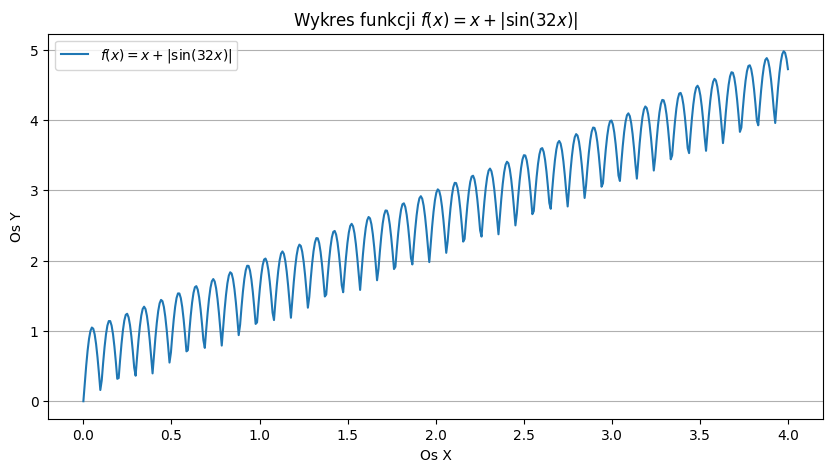

In [ ]:
# from matplotlib import pyplot as plt

## Wersja oparta na rysowaniu funkcji

def f(x):
    return x + np.abs(np.sin(32*x))

# Wektor wejciowy (dziedzina) i obliczony wyjciowy (wartości funkcji)
x_values = np.linspace(0, 4, 500)
y_values = f(x_values)

# Rysowanie
plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, label=r'$f(x) = x + |\sin(32x)|$')
plt.xlabel('Os X')
plt.ylabel('Os Y')
plt.title('Wykres funkcji $f(x) = x + |\sin(32x)|$')
plt.grid(axis = 'y')
plt.legend()
plt.show()

Okazuje się, że jest to funkcja okresowo rosnąca a w punkcie 4 ma wartość, którą możemy oszacować jako 4,7. Jednak maksimum globalne dla danej funkcji (oraz przedziału) jest obok - po lewej stronie.

### **Zad 2.** Napisz program, który będzie wyszukiwał maximum funkcji metodą spadku gradientu, dla: $\qquad f(x) = x + |\sin(32x)|,\quad gdzie: x \in (0, 4].\quad$


Wyszukiwanie maksimum metodą spadku gradientu opiera się na poszukiwaniu w kierunku najszybszych zmian funkcji, co obrazuje przebieg pochodnej danej funkcji.

In [ ]:
## Wersja metodą spadku gradientu

def f(x):
    return x + np.abs(np.sin(32*x))

# Definicja pochodnej

def grad_f(x):
    sign_sin = np.sign(np.sin(32*x))
    return 1 + 32 * sign_sin * np.sin(32*x)

# Ograniczenie przedziału wartosci funkcji oraz sledzienie gradientu (ascent)

def gradient_ascent(x_start, learning_rate=0.01, max_iterns=1000, tol=1e-1, x_max_limit=4):
    x = x_start                             # inicjacja x
    for _ in range(max_iterns):             # pętla for od 0 do max_iterns
        x_new = x + learning_rate * grad_f(x)    # do x_new podstaw x + człon nagrody (kary)
        if x_new > x_max_limit:             # czy osiągnięto koniec przedziału x
            x_new = x_max_limit             # jesli tak .. ustaw x_new na x_max_limit
            break                           # .. i koniec pętli
        if abs(x_new - x) < tol:            # jesli przyrosty małe..
            break                           # .. wyjdź z pętli
        x = x_new                           # do x przypisz obliczone x_new
    return x, f(x)                          # zwróć x i f(x)

# Użycie kodu x_start = 0.01

x_start = 0.01
x_max, f_max = gradient_ascent(x_start)

print(f"Maksimum osiągnięte to f(x) =  {f_max} dla wartosci x = {x_max} - punkt startu = {x_start}")


# Użycie kodu x_start = 0.02

x_start = 0.02
x_max, f_max = gradient_ascent(x_start)

print(f"Maksimum osiągnięte to f(x) =  {f_max} dla wartosci x = {x_max} - punkt startu = {x_start}")

Maksimum osiągnięte to f(x) =  3.0904101645646107 dla wartosci x = 2.9496563250319556 - punkt startu = 0.01
Maksimum osiągnięte to f(x) =  4.945782138891172 dla wartosci x = 3.9692890269124628 - punkt startu = 0.02


Doświadczalnie dobrana wartość x_start na poziomie 0.02 daje dobre przybliżenie wyniku, jednak jest to przypadkowe zachowanie algorytmu. Dla małych x_start (do wartości 0.01) wynik prawie nie zmienia się. Dla dużych jest zupełnie niereprezentatywna. Można by też ekserymentować z krokiem uczenia, jednak trzeba uznać metodę za nie dokładną.

###**Zad. 3.** Napisz program w Pythonie, który realizuje losowe przeszukiwanie przestrzeni rozwiązań w celu znalezienia maksimum funkcji $\qquad f(x) = x + |\sin(32x)|,\quad gdzie: x \in [0, 4].\quad$

Kolejną metodą, której można by się przyjrzeć jest metoda losowa, gdzie maksimum szukamy w sposób losowy (powiedzmy "na ślepo").

In [ ]:
# Definicja funkcji zadanej f(x)

def f(x):
    return x + np.abs(np.sin(32*x))

# Iterator, max i min przedziału

max_iterns = 100
x_min = 0
x_max = 4

# Inicjacja wartości wyniku - przypadek startowy (najgorszy wynik)

best_x = 0
best_value = 0

# Algorytm poszukiwania

for _ in range(max_iterns):
  x_random = np. random.uniform(x_min, x_max)     # Losowanie z zadanego przedziału
  value = f(x_random)                             # Przypisanie f(x) dla losowego 'x'

  if value > best_value:                          # Warunek najwyższego wyniku
    best_value = value
    best_x = x_random

# Wyprowadzenie wyniku

print(f"Maksimum osiągnięte to f(x) =  {best_value} dla wartosci x = {best_x} - Ilosc iteracji = {max_iterns}")

Maksimum osiągnięte to f(x) =  4.937519020802361 dla wartosci x = 3.9683040141802035 - Ilosc iteracji = 100


Przygotowany kod przeszukuje zakres dziedziny i wartości funkcji, gdzie rozpoczyna od początku układu tj. punktu (0, 0) i zastępuje kolejne wartości w kolejnych iteracjach - większymi napotkanymi, tak by znaleźć max (najlepszy jaki uda się wylosować). Wyświetla wynik f(x) oraz dla jakiej wartości 'x'. Kod zgodnie z przypuszczeniami daje losowe wyniki, jednak dosyć dobre. Nawet przy tylko 10-ciu iteracjach. Proste są także założenia startowe.

###**Zad. 4.** Kod z poprzedniego zadania uzupełnij o zmienne do przechowywania wyników z poprzedniego kroku oraz poleceniem do wyświetlenia na ekranie wartości ze wszystkich kroków i wykresu funkcji pokazującej najlepsze w danym kroku rozwiązanie

Poniżej modyfikacja zadania poprzedniego. Opis programu pod treścią.

Maksimum osiągnięte to f(x) =  3.8935857474060724 dla wartosci x = 2.894688202775321 - Ilosc iteracji = 15
Kolejne pary wyników:
Pokolenie 1: f(x) = 1.8292067810436003  dla  x = 1.6637775592890547
Pokolenie 2: f(x) = 3.8935857474060724  dla  x = 2.894688202775321
Pokolenie 3: f(x) = 3.5621226237719155  dla  x = 2.7174579989530945
Pokolenie 4: f(x) = 3.1710732572083016  dla  x = 2.9521406261420444
Pokolenie 5: f(x) = 2.4520250337438267  dla  x = 1.5344888382388184
Pokolenie 6: f(x) = 2.5218874736822174  dla  x = 1.523463827944334
Pokolenie 7: f(x) = 2.118977570456648  dla  x = 1.242907965063234
Pokolenie 8: f(x) = 1.094307466831419  dla  x = 0.4697955247876311
Pokolenie 9: f(x) = 0.6519935258836764  dla  x = 0.5909571942090692
Pokolenie 10: f(x) = 1.9029122727436805  dla  x = 0.9259408420448554
Pokolenie 11: f(x) = 3.3414330401792878  dla  x = 3.3378295862604914
Pokolenie 12: f(x) = 2.3983814164431423  dla  x = 1.431613046983569
Pokolenie 13: f(x) = 0.6892322432928366  dla  x = 0.687284

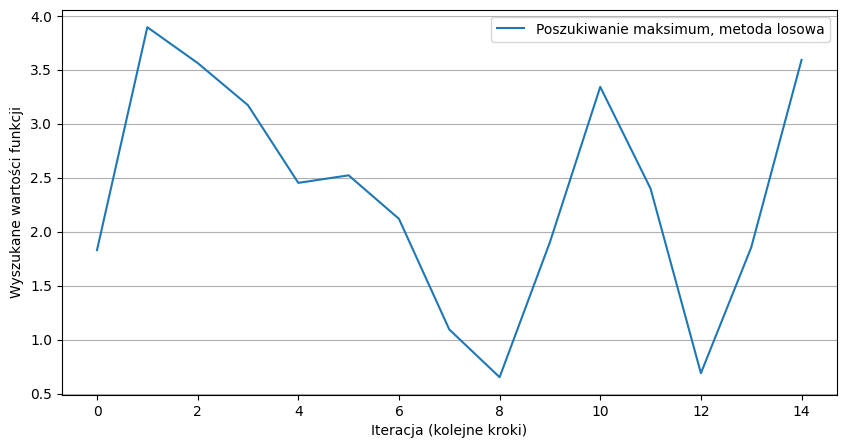

In [ ]:
# Definicja funkcji zadanej f(x)

def f(x):
    return x + np.abs(np.sin(32*x))

# Iterator, max i min przedziału

max_iterns = 15
x_min = 0
x_max = 4

# Inicjacja początkowej wartości wyniku oraz list do przechowania wyników

best_x = 0
best_value = 0
tab_x = []              # Tablica (lista) x
tab_value = []          # Tablica (lista) f(x)

# Algorytm poszukiwania

for _ in range(max_iterns):
  x_random = np. random.uniform(x_min, x_max)
  value = f(x_random)

  tab_x.append(x_random)      # Dodanie wartości do tablicy x
  tab_value.append(value)     # Dodanie wartości do tablicy f(x)

  if value > best_value:
    best_value = value
    best_x = x_random

# Wyprowadzenie wyniku

print(f"Maksimum osiągnięte to f(x) =  {best_value} dla wartosci x = {best_x} - Ilosc iteracji = {max_iterns}")

# Wyprowadzenie wartości tablic

print("Kolejne pary wyników:")
for i, (x, y) in enumerate(zip(tab_x, tab_value)):    # Zip łączy listy w pary
    print(f"Pokolenie {i+1}: f(x) = {y}  dla  x = {x}")       # .. są numerowane

# Przygotowanie wykresu

plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), tab_value, label='Poszukiwanie maksimum, metoda losowa')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji')
plt.grid(axis = 'y')
plt.legend()
plt.show()


Dodano listy tab_x oraz tab_value, które są zapełniane w pierwszej pętli for. Z kolei druga pętla for posiada iterator i łączy ze sobą obie listy (funkcja 'zip') oraz numeruje kolejne pary (funkcja 'enumerate'). Iteracje są wyprowadzane metodą print() do konsoli. Wykres przygotowano podobnie jak w zadaniu 1 przy użyciu biblioteki matplotlib. Metoda jest chaotyczna - zupełnie niepowtarzalna, co prezentuje sporządzony wykres.


###**Zad. 5.** Napisz program w Python implementujący algorytm ewolucyjny do znajdowania maksimum funkcji w przedziale: $\qquad f(x) = x + |\sin(32x)|,\quad gdzie: x \in [0, 4].\quad$
### Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim rozwiązaniem.

Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.559863056356073 dla x = 3.666958841701836
Najgorszy osobnik: f(x) = 4.315141177338307 dla x = 3.467714449026876
Średnia populacji: 4.494219391487743
Liczba najlepszych osobników: 13


Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.592365050277493 dla x = 3.6692220391931967
Najgorszy osobnik: f(x) = 3.906377469035755 dla x = 3.7359919297748116
Średnia populacji: 4.5288138766861294
Liczba najlepszych osobników: 1


Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.582466719093151 dla x = 3.586010917474697
Najgorszy osobnik: f(x) = 4.551839750291811 dla x = 3.5764340537876866
Średnia populacji: 4.5698577286693265
Liczba najlepszych osobników: 1


Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.57670970086446 dla x = 3.668090440447516
Najgorszy osobnik: f(x) = 3.799490890017256 dla x = 3.6270506789611066
Średnia populacji: 4.130690047269925
Liczba najlepszych osobników: 6


Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.583694013583119 dla x = 3.584938

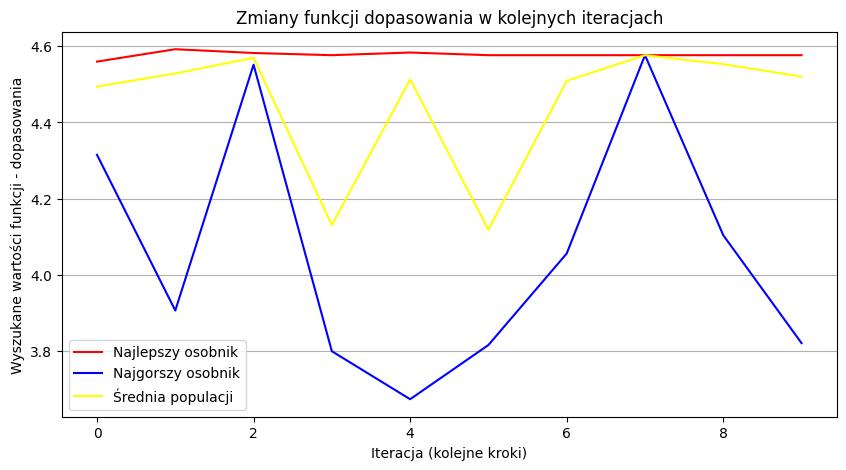

In [ ]:
# Definicja funkcji zadanej f(x)

def f(x):
  return x + np.abs(np.sin(32*x))

# Parametry inicjacji algorytmu ewolucyjnego
x_min, x_max = 0, 4             # Zakres dziedziny
population_size = 20            # Liczność populacji
max_iterns = 10                 # Liczba iteracji
mutation_rate = 0.1             # Wskaźnik szybkości mutacji
crossover_rate = 0.7            # Wskaźnik szybkości krzyżowania

# Definicja zmiennych pomocniczych - tablic dopasowania w kolejnych pokoleniach
best_fit = []
worst_fit = []
avg_fit = []
optimal = []

# Definicja populacji
population = np.random.uniform(0, 4, population_size)   # Losowanie osobników

# Selekcja najlepiej przystosowanych osobników (definicja funkcji selekcji)
def selection(population):
  fit = np.array([f(x) for x in population])    # Funkcja celu (dopasowania)
  indexes = np.argsort(fit)[-2:]                # Wybór najlepiej przystosowanych osobników
  return population[indexes]                    # Zwracamy tych dwóch najlepszych

# Krzyżowanie cech/genów dla 2-ch osobnoków
def crossover(parent1, parent2):
  if np.random.random() < crossover_rate:       # Prawdopodobieństwo krzyżowania
    return (parent1 + parent2) / 2              # Średnia jeśli skrzyżowano
  return (parent1)                              # Cechy pierwszego w całości

# Mutowanie cech - zmiana wartości (względnie małego rzędu)
def mutation(x):
  if np.random.random() < mutation_rate:         # Prawdopodobieństwo mutacji
    x = x + (np.random.uniform(-0.1, 0.1))       # Mutowanie wartością z przedziału [-0.1, 0.1]
    x = np.clip(x, x_min, x_max)                 # Strażnnik wartości granicznych
  return x                                       # Zwraca nowego osobnika

# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population = []

  while len(new_population) < population_size:    # Zapełnianie populacji
    parent1, parent2 = selection(population)      # Selekcja
    child = crossover(parent1, parent2)           # Krzyżowanie
    child = mutation(child)                       # Mutacja
    new_population.append(child)                  # Dodanie nowego osobnika do populacji

  population = np.array(new_population)           # Zapisanie stanu populacji

# Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

# Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

# Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

# Średnia populacji
  avg = np.mean(fit)

# Ilość najlepszych osobników
  best_count = np.sum(fit == best_value)

# Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

# Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")
  print(f"Liczba najlepszych osobników: {best_count}\n\n")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()



W programie utworzono funkcje selekcji, krzyżowania i mutacji.
W funkcji selekcji <selection(population)> określono poziom dopasowania, następnie wybrano 2ch najlepszych osobników z puli i zwrócono ich wartości dopasowania. Sama selekcja, jako, że pobiera 2ch najlepiej przystosowanych jest nazywa czasem, selekcją elitarną.

W funkcji krzyżowania <crossover(parent1, parent2)> jest losowana wartość prawdopodobieństwa wystąpienia krzyżowania. Jeśli wylosowano mniejsze niż wskaźnik szybkości krzyżowania tworzony jest osobnik o wspólnych cechach (suma cech dzielona przez 2). Jeśli większe nowy osobnik przejmuje cechy pierwszego rodzica w całości.

W funkcji mutacji <mutation(x)> do wartości cechy dodajemy niewielki składnik losowy - dodatni lub ujemny na poziomie zmienności do 10%. "Strażnik wartości granicznych" utrzymuje wartość w zakresie [0, 4] nie pozwalając wyjść poza zakres - dla x < 0 = 0  dla x > 4 = 4.

Następnie wchodzimy do Głównej pętli algorytmu. Wybieramy 2ch wskazanych przez selekcję osobników, krzyżujemy, mutujemy i dodajemy do populacji nowego osobnika tak długo aż zapełnimy przewidzianą liczność populacji. Zapisujemy nowe pokolenie do zmiennej <population>. Wyznaczamy wartości funkcji f(x) dla wszystkich osobników - jako ocenę dopasowania. Wybieramy najlepszego osobnika (najlepiej przystosowanego, tzn. z najwyższą wartością funkcji dopasowania) oraz analogicznie najgorszego, a także przeciętnego (średnia populacji). Wynik dodajemy do tablic przechowujących powyższe 3 wartości (max, min, avg) na przestrzeni ilości pokoleń (max_iterns). Określamy jeszcze liczbę najlepiej przystosowanych osobników. Wyniki wyprowadzamy na konsolę. Tu pętla kończy iterację i zaczyna kolejną. Wykonuje się tyle razy ile pokoleń ustalono.

Na koniec program wyświetla najlepsze osiągnięte wyniki i przygotowuje wykres zmienności maksimum, minimum i wartości średniej dla kolejnych iteracji (pokoleń).

W programie ustawiono wartości inicjujące: rozmiar populacji 20, ilość pokoleń 10, prawdopodobieństwo mutacji (0.3) - 30%, prawdopodobieństwo krzyżowania (0.7) - 70%.

Jeśli chodzi o dyskusję wyników, trudno wskazać coś powtarzalnego dla losowo uruchomionego zestawu danych (kolejne uruchomienia skryptu). W pojedynczej próbie wyniki w kolejnych pokoleniach różnią się między sobą. Dla najlepiej przystosowanyh są to zmmiany wręcz pełzające - wyglądają na pochodzące z względnie małego zakresu - czasem o losowym charakterze, czasem popadają w stagnację. Wartość zmienności średniej oraz najsłabszej części populacji zwykle zmienia się skokowo. Najsilniejsza reprezentacja zasadniczo przedstawia wykres, który z przybliżeniem można uznać za liniowy. Co oznacza, że optymalne rozwiązanie dla całego trwania doświadczenia (wszystkie pokolenia), dają niezbyt dobry wynik, biorąc pod uwagę użycie metody, po której można by spodziewać się większej jakości obliczeń. Zastanawiąjące jest, że średnia populacji i najgorsze przypadki są skokowe, podczas gdy "elitarnie wyselekcjonowane" osobniki utrzymują stałość cech. Na pewno duży wpływ na jakość rozwiązania (jeśli nie krytyczny) mają wybrane wartości parametrów. Tu trzeba by zająć się kwestią strategii prowadzenia doświadczenia i doboru parametrów.